## Testing Sequence Counts


Calculate the total number of unique sequences in a given data file.

In [1]:
import os
import shutil
import pandas as pd
import numpy as np
import torch
from transformers import AutoModel, AutoTokenizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import pickle
import time

In [2]:
def load_codoncounts(filepath):
    """Load in the dataframe for the codoncounts file"""
    df = pd.read_csv(filepath)
    column_names = df.columns.tolist()
    column_names = column_names[2:]
    wildtypes = df["wildtype"].tolist()
    df = df.drop(columns=["site", "wildtype"])
    df_array = df.to_numpy()
    return df_array, column_names, wildtypes

def count_unique_proteins(filepath=None, codon_array=None, 
                          column_names=None, wildtypes=None):
    """Count the number of unique proteins in the codon array"""
    if filepath is not None:
        codon_array, column_names, wildtypes = load_codoncounts(filepath)
    else:
        assert codon_array is not None
        assert column_names is not None
        assert wildtypes is not None
    
    count_unique = 0
    # iterate through each row
    for i in range(codon_array.shape[0]):
        row = codon_array[i]
        for j in range(row.shape[0]):
            if row[j] > 0 and column_names[j] != wildtypes[i]:
                count_unique += 1
    return count_unique

def get_reference_sequence(filepath):
    """Get the reference sequence from a text file"""
    with open(filepath, 'r') as f:
        reference_sequence = f.read().strip()
    
    reference_protein_sequence = ""
    for i in range(0, len(reference_sequence), 3):
        codon = reference_sequence[i:i+3]
        aa = CODON2AA.get(codon, 'X')  # Use 'X' for unknown codons
        reference_protein_sequence += aa
    return reference_protein_sequence


def get_day_estimate(filepath):
    codon_array, column_names, wildtypes = load_codoncounts(filepath)
    total_unique = count_unique_proteins(codon_array=codon_array, 
                                         column_names=column_names, 
                                         wildtypes=wildtypes)
    row_number = codon_array.shape[0] # number of sites
    day_estimate = total_unique * row_number / 100000
    return day_estimate

def count_total_proteins(filepath):
    """Sum the total number of proteins in a single row"""
    codon_array, column_names, wildtypes = load_codoncounts(filepath)
    # sum along the first row
    total_proteins = np.sum(codon_array[0, :])
    return total_proteins
    


## Reconstructing the Amino Acid Sequences from the codon counts files

In [3]:
pwd = os.getcwd()

data_dir = pwd + '/data/raw_data/'
test_file = data_dir + 'BF520_mutDNA-1_codoncounts.csv'
reference_sequence_file = data_dir + "BF520_Reference_sequence.txt"

In [4]:
# The ending file has more unique proteins than the beginning? I guess some mutations occured

print(count_unique_proteins(filepath=data_dir+'BF520_mutDNA-1_codoncounts.csv'))
print(count_unique_proteins(filepath=data_dir+'BF520_mutvirus-1_codoncounts.csv'))
print(get_day_estimate(test_file))
print(count_total_proteins(data_dir+'BF520_mutDNA-1_codoncounts.csv'))
print(count_total_proteins(data_dir+'BF520_mutvirus-1_codoncounts.csv'))

38187
26172
252.79794
243572
153447


In [4]:
CODON2AA = {'ATA':'I', 'ATC':'I', 'ATT':'I', 'ATG':'M',            # Map from codons to amino acids
            'ACA':'T', 'ACC':'T', 'ACG':'T', 'ACT':'T',
            'AAC':'N', 'AAT':'N', 'AAA':'K', 'AAG':'K',
            'AGC':'S', 'AGT':'S', 'AGA':'R', 'AGG':'R',
            'CTA':'L', 'CTC':'L', 'CTG':'L', 'CTT':'L',
            'CCA':'P', 'CCC':'P', 'CCG':'P', 'CCT':'P',
            'CAC':'H', 'CAT':'H', 'CAA':'Q', 'CAG':'Q',
            'CGA':'R', 'CGC':'R', 'CGG':'R', 'CGT':'R',
            'GTA':'V', 'GTC':'V', 'GTG':'V', 'GTT':'V',
            'GCA':'A', 'GCC':'A', 'GCG':'A', 'GCT':'A',
            'GAC':'D', 'GAT':'D', 'GAA':'E', 'GAG':'E',
            'GGA':'G', 'GGC':'G', 'GGG':'G', 'GGT':'G',
            'TCA':'S', 'TCC':'S', 'TCG':'S', 'TCT':'S',
            'TTC':'F', 'TTT':'F', 'TTA':'L', 'TTG':'L',
            'TAC':'Y', 'TAT':'Y', 'TAA':'*', 'TAG':'*',
            'TGC':'C', 'TGT':'C', 'TGA':'*', 'TGG':'W' }

In [5]:
def write_codon_replicates(replicates_pre: list, replicates_post: list, output_path: str, reference_seq: str):
    """Write the codon changes from multiple replicates to a single file"""
    assert len(replicates_pre) == len(replicates_post), "Number of pre and post replicate files must be the same"
    codon_arrays_pre = []
    codon_arrays_post = []
    loaded_wildtypes, loaded_columns = False, False
    wildtypes_master = []
    columns_master = []
    for filepath in replicates_pre:
        codon_array, column_names, wildtypes = load_codoncounts(filepath)
        codon_arrays_pre.append(codon_array)
        if not loaded_wildtypes:
            loaded_wildtypes = True
            wildtypes_master = wildtypes
        if not loaded_columns:
            loaded_columns = True
            columns_master = column_names
        assert (wildtypes == wildtypes_master), "Wildtypes do not match across replicates"
        assert (column_names == columns_master), "Column names do not match across replicates"
    
    for filepath in replicates_post:
        codon_array, column_names, wildtypes = load_codoncounts(filepath)
        codon_arrays_post.append(codon_array)
        assert (wildtypes == wildtypes_master), "Wildtypes do not match across replicates"
        assert (column_names == columns_master), "Column names do not match across replicates"
        
    column_names_aa = [CODON2AA.get(codon, 'X') for codon in columns_master]
    wildtypes_aa = [CODON2AA.get(codon, 'X') for codon in wildtypes_master]
    new_prot_seqs = []
    pre_num_array = []
    post_num_array = []
    with open (output_path, 'w') as f:
        f.write("PreNums,PostNums,ProteinSequence\n")
        # Iteratre through each row
        for i in range(codon_arrays_pre[0].shape[0]):
            rows_pre = [pre_array[i] for pre_array in codon_arrays_pre]
            rows_post = [post_array[i] for post_array in codon_arrays_post]
            for j in range(rows_pre[0].shape[0]):
                if column_names_aa[j] != wildtypes_aa[i]:
                    pre_nums = [int(pre_row[j]) for pre_row in rows_pre]
                    post_nums = [int(post_row[j]) for post_row in rows_post]
                    
                    pre_num_array.append(pre_nums)
                    post_num_array.append(post_nums)
                    
                    amino_acid = column_names_aa[j]
                    
                    new_prot_seq = reference_seq[:i] + amino_acid + reference_seq[i+1:]
                    new_prot_seqs.append(new_prot_seq)
                    f.write(f"{pre_nums},{post_nums},{new_prot_seq}\n")
                    
    # save a pickle dataframe too
    
    new_df = pd.DataFrame({
        'PreNums': pre_num_array,
        'PostNums': post_num_array,
        'ProteinSequence': new_prot_seqs
    })
    new_df.to_pickle(output_path.replace('.csv', '.pkl'))
        
    
   
    

In [18]:
output_file = pwd + '/data/sequence_data/r3_BF520_protein_sequences.csv'

write_codon_begin_and_end(data_dir+'BF520_mutDNA-3_codoncounts.csv',
                            data_dir+'BF520_mutvirus-3_codoncounts.csv',
                            output_file,
                            get_reference_sequence(reference_sequence_file))

NameError: name 'write_codon_begin_and_end' is not defined

In [19]:


pwd = os.getcwd()

data_dir = pwd + '/data/raw_data/'
reference_sequence_file = data_dir + "BF520_Reference_sequence.txt"
output_file = pwd + '/data/sequence_data/all_reps_BF520_protein_sequences.csv'

pre_selection_files = [data_dir+'BF520_mutDNA-1_codoncounts.csv',
                       data_dir+'BF520_mutDNA-2_codoncounts.csv',
                       data_dir+'BF520_mutDNA-3_codoncounts.csv']

post_selection_files = [data_dir+'BF520_mutvirus-1_codoncounts.csv',
                        data_dir+'BF520_mutvirus-2_codoncounts.csv',
                        data_dir+'BF520_mutvirus-3_codoncounts.csv']


write_codon_replicates(pre_selection_files,
                            post_selection_files,
                            output_file,
                            get_reference_sequence(reference_sequence_file))

In [6]:
def embed_sequence(sequence: str, tokenizer, model) -> np.ndarray:
    """Embed the sequence to a fixed size vector using ESM-2"""

    inputs = tokenizer(sequence, return_tensors="pt", add_special_tokens=True)
    with torch.no_grad():

        outputs = model(**inputs, output_hidden_states=True)
        hidden_states = outputs.hidden_states


    output_embeddings = []
    for layer in hidden_states:
        token_representations = layer
        
        print(token_representations.shape)
        print(token_representations)
        
        
        
        #print(token_representations.shape)  # Shape: (1, sequence_length, embedding_dim)        s
        sequence_embedding = pool_sequence_representation(token_representations, inputs)
        output_embeddings.append(sequence_embedding)
        #print(sequence_embedding.shape)  # Shape: (embedding_dim,)
    return np.vstack(output_embeddings)  # Shape: (num_layers, embedding_dim)

def pool_sequence_representation(token_representations, inputs) -> np.ndarray:
    """Pool the token representations to get a fixed-size sequence representation."""
    # token_representations shape: (1, sequence_length, embedding_dim)
    # inputs['attention_mask'] shape: (1, sequence_length)
    attention_mask = inputs['attention_mask']
    masked_representations = token_representations * attention_mask.unsqueeze(-1)
    summed = masked_representations.sum(dim=1)
    counts = attention_mask.sum(dim=1).unsqueeze(-1)
    pooled_representation = summed / counts
    return pooled_representation.squeeze(0).cpu().numpy()  # Shape: (embedding_dim,)

In [7]:
def embed_replicates(embedding_df: pd.DataFrame, 
                     output_path: str,
                     embed_zeroes: bool=False,
                     esm_model: str="facebook/esm2_t30_150M_UR50D") -> None:
    """Embed the sequeunces given the replicates embedding dataframe from
    write_codon_replicates() """
    start_time = time.time()
    pre_counts = embedding_df["PreNums"].to_list()
    post_counts = embedding_df["PostNums"].to_list()
    
    tokenizer = AutoTokenizer.from_pretrained(esm_model, do_lower_case=False)
    model = AutoModel.from_pretrained(esm_model)
    
    embeddings = []
    for i, prot_sequence in enumerate(embedding_df["ProteinSequence"].to_list()):
        if embed_zeroes:
            embedding = embed_sequence(prot_sequence, tokenizer, model)
            embeddings.append(embedding)
        else:
            if any([x > 0 for x in pre_counts[i]]):
                embedding = embed_sequence(prot_sequence, tokenizer, model)
                embeddings.append(embedding)
            else:
                embeddings.append(None)
        if i % 100 == 0:
            cur_time = time.time()
            estimate_remaining = (cur_time - start_time) / (i + 1) * (len(embedding_df) - (i + 1))
            print(f"Embedded {i} sequences, time elapsed: {cur_time - start_time:.2f} seconds, estimated time remaining: {estimate_remaining/60:.2f} minutes")
    
    
    #embedding_df['Embeddings'] = embeddings
    #embedding_df.to_pickle(output_path)
    #print(f"Wrote embeddings to {output_path}")
    
    
    

In [28]:
# Load in the pickle filke
embedding_df = pd.read_pickle(pwd + '/data/sequence_data/all_reps_BF520_protein_sequences.pkl')

print(len(embedding_df["ProteinSequence"][0]))

embedding_df["ProteinSequence"][0] = "MKTIIALSYIFCLVFADYKDDDDK"

embed_replicates(embedding_df, pwd + '/data/sequence_data/all_reps_BF520_protein_embeddings.pkl', embed_zeroes=False)

662


/var/folders/yv/3g8ggfl9341blgk0mn8sq6_c0000gn/T/ipykernel_52674/291722162.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  embedding_df["ProteinSequence"][0] = "MKTIIALSYIFCLVFADYKDDDDK"
Some weights of EsmModel were not initialized from

Embedded 0 sequences, time elapsed: 0.27 seconds, estimated time remaining: 183.74 minutes
torch.Size([1, 664, 640])
tensor([[[ 0.1483,  0.0149, -0.0419,  ..., -0.1351,  0.1505,  0.1219],
         [-0.0565, -0.1022, -0.0616,  ..., -0.0796,  0.1048, -0.0048],
         [-0.0361, -0.0541, -0.0863,  ...,  0.0662, -0.0520,  0.0405],
         ...,
         [-0.0495, -0.0290, -0.0480,  ...,  0.1085,  0.0263,  0.0266],
         [-0.0265, -0.0223, -0.0304,  ..., -0.0548, -0.1575, -0.0085],
         [ 0.1317, -0.0549, -0.2464,  ..., -0.2576,  0.1824,  0.1376]]])
torch.Size([1, 664, 640])
tensor([[[ 0.6976,  0.3297,  0.3137,  ..., -0.8759,  0.2666,  0.1670],
         [ 0.6687,  0.1646, -0.2007,  ...,  0.7688, -0.5736,  0.0703],
         [ 0.7268,  0.4006, -0.0476,  ...,  0.5777,  0.0268, -0.1588],
         ...,
         [ 0.5491,  0.5755, -0.1861,  ..., -0.8121, -0.2470,  0.0813],
         [ 0.5313,  0.7221,  0.2708,  ..., -0.8280, -0.6237, -0.8015],
         [ 0.5745,  0.4131,  0.0464,  ..., -1.

KeyboardInterrupt: 

In [81]:
print(embedding_df["Embeddings"][4].shape)

(31, 640)


In [7]:
# Now, let's analyze these dang embeddings
def calc_cov_mats(embeddings: np.ndarray, pre_weights: np.ndarray, 
                  post_weights: np.ndarray, layer: int = None) -> np.ndarray:
    """
    Calculate the covariance matrices for the before and after counts
    embeddings: 3 dimensional array of shape (num_sequences, num_layers, embedding_dim)
    layer: which layer to use for the embeddings, if None, use all layers
    """
    
    if layer is not None:
        embeddings = embeddings[:, layer, :]
        
    
    before_cov = np.cov(embeddings.T, aweights=pre_weights)
    after_cov = np.cov(embeddings.T, aweights=post_weights)
    return before_cov, after_cov

def calc_cov_mats_reps(embeddings: np.ndarray, pre_weights: np.ndarray, 
                       post_weights: np.ndarray, layer: int = None) -> np.ndarray:
    """
    Calculate the covariance matrices for the before and after counts
    embeddings: 3 dimensional array of shape (num_sequences, num_layers, embedding_dim)
    layer: which layer to use for the embeddings, if None, use all layers
    """
    num_reps = pre_weights.shape[1]
    if layer is not None:
        embeddings = embeddings[:, layer, :]
        
    before_covs = []
    after_covs = []
    for rep in range(num_reps):
        before_cov = np.cov(embeddings.T, aweights=pre_weights[:, rep])
        after_cov = np.cov(embeddings.T, aweights=post_weights[:, rep])
        before_covs.append(before_cov)
        after_covs.append(after_cov)
    return before_covs, after_covs

In [9]:
embedding_df = pd.read_pickle(pwd + '/data/sequence_data/all_reps_BF520_protein_embeddings.pkl')
#nonzero_df = embedding_df[embedding_df["Embeddings"].notnull()].reset_index(drop=True)

#pre_weights = np.array([np.array(x) for x in nonzero_df["PreNums"].to_list()])
#post_weights = np.array([np.array(x) for x in nonzero_df["PostNums"].to_list()])
#embeddings = np.array([x for x in nonzero_df["Embeddings"].to_list()])

In [89]:
before_cov, after_cov = calc_cov_mats_reps(embeddings, pre_weights, post_weights, layer=29)

In [90]:
cov_diffs = [after - before for before, after in zip(before_cov, after_cov)]

In [10]:
# Plot the differences
import matplotlib.pyplot as plt
for i, cov_diff in enumerate(before_cov):
    plt.figure(figsize=(10, 8))
    plt.style.use("seaborn-v0_8-dark")
    plt.imshow(cov_diff, cmap='bwr', vmin=-np.max(np.abs(cov_diff)), vmax=np.max(np.abs(cov_diff)))
    plt.colorbar(label='Covariance Difference')
    plt.title(f'Covariance Before for Replicate {i+1}')
    plt.xlabel('Embedding Dimension')
    plt.ylabel('Embedding Dimension')
    plt.tight_layout()
    plt.show()

NameError: name 'before_cov' is not defined

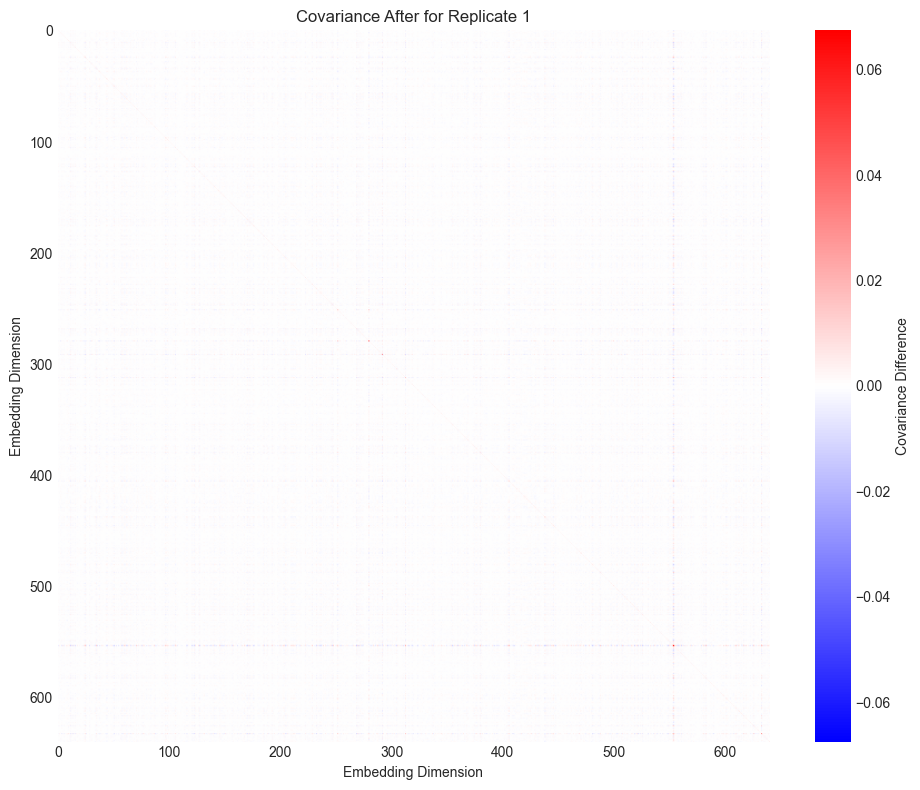

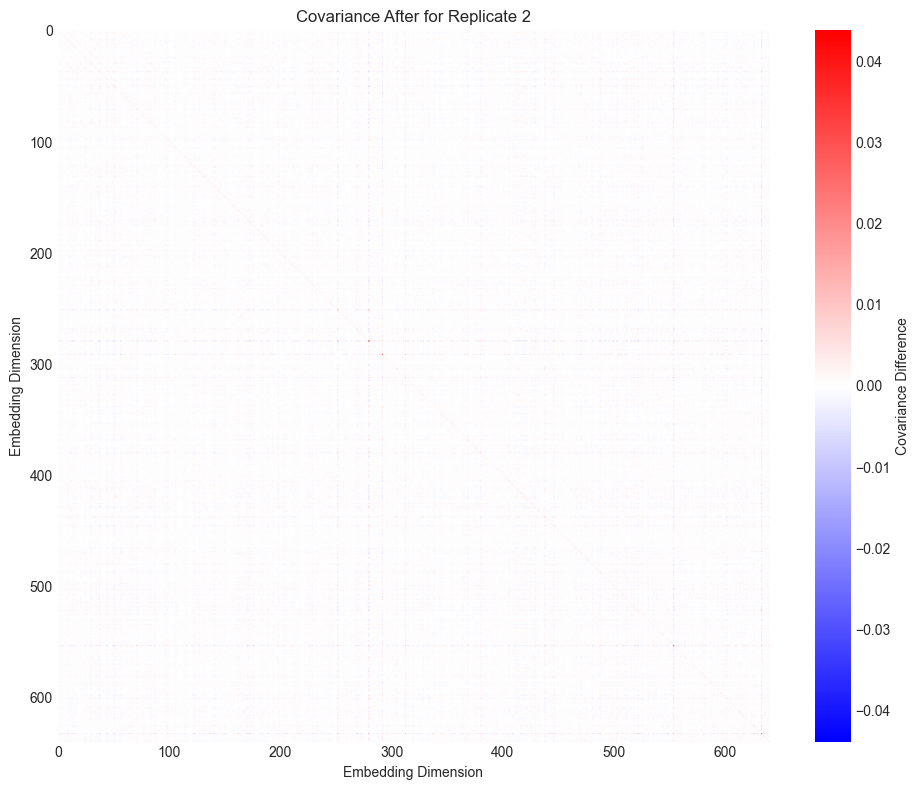

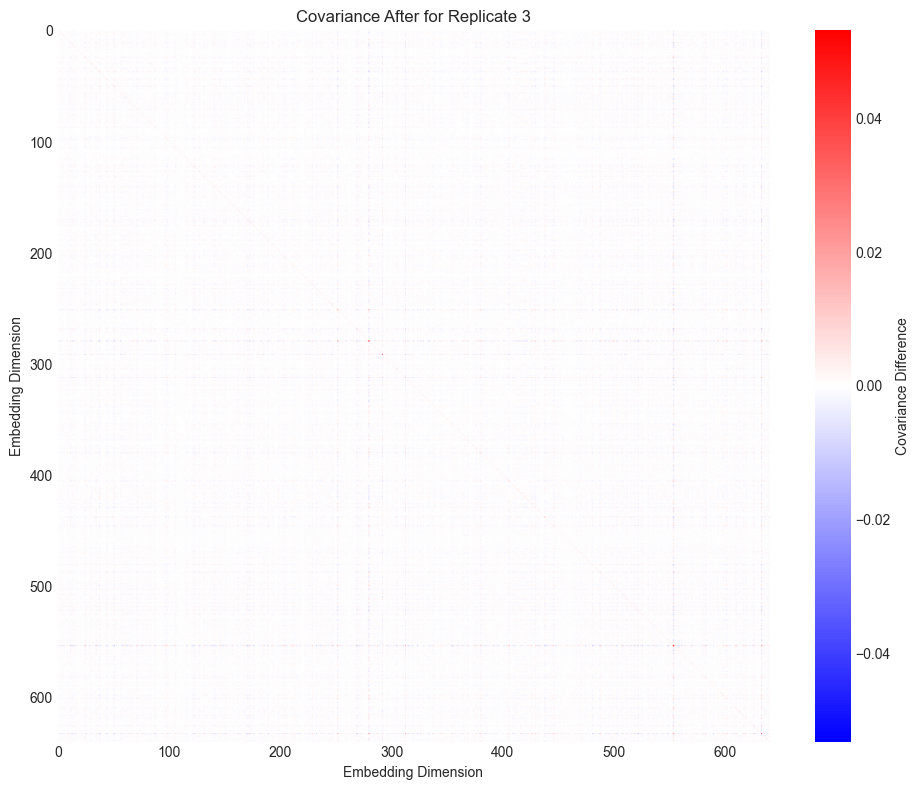

In [99]:
# Plot the differences
import matplotlib.pyplot as plt
for i, cov_diff in enumerate(after_cov):
    plt.figure(figsize=(10, 8))
    plt.style.use("seaborn-v0_8-dark")
    plt.imshow(cov_diff, cmap='bwr', vmin=-np.max(np.abs(cov_diff)), vmax=np.max(np.abs(cov_diff)))
    plt.colorbar(label='Covariance Difference')
    plt.title(f'Covariance After for Replicate {i+1}')
    plt.xlabel('Embedding Dimension')
    plt.ylabel('Embedding Dimension')
    plt.tight_layout()
    plt.show()

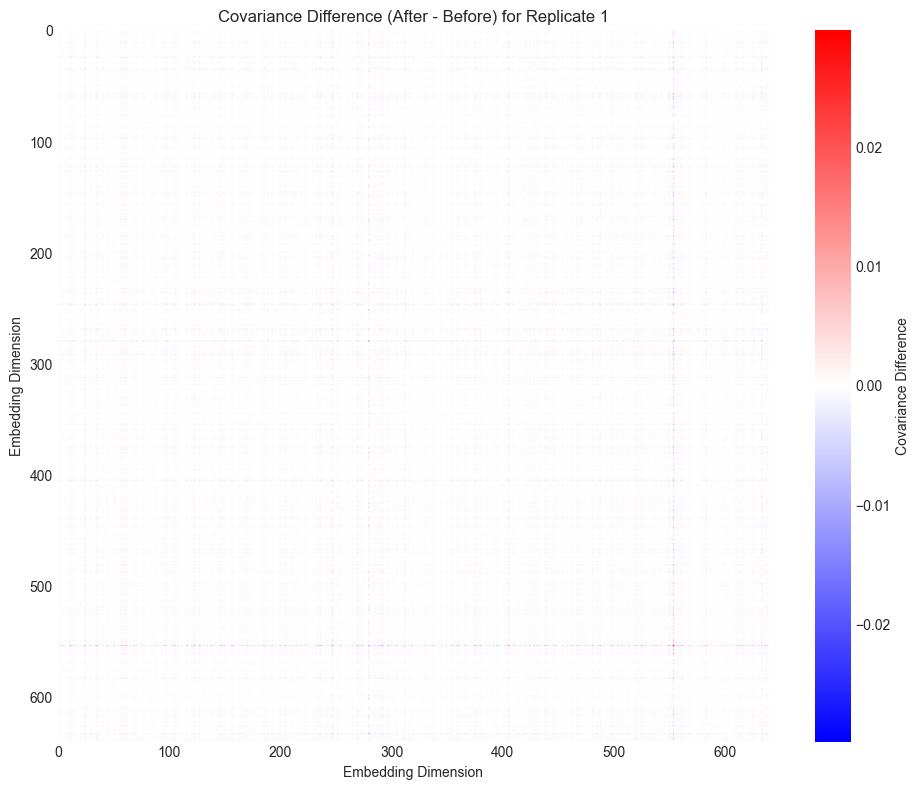

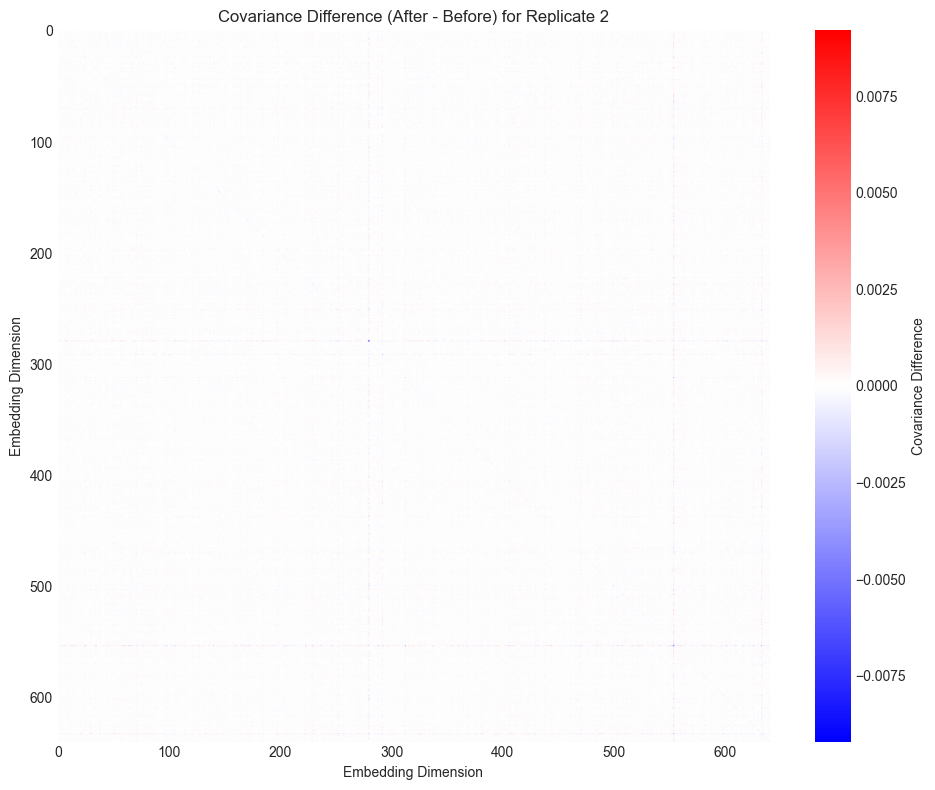

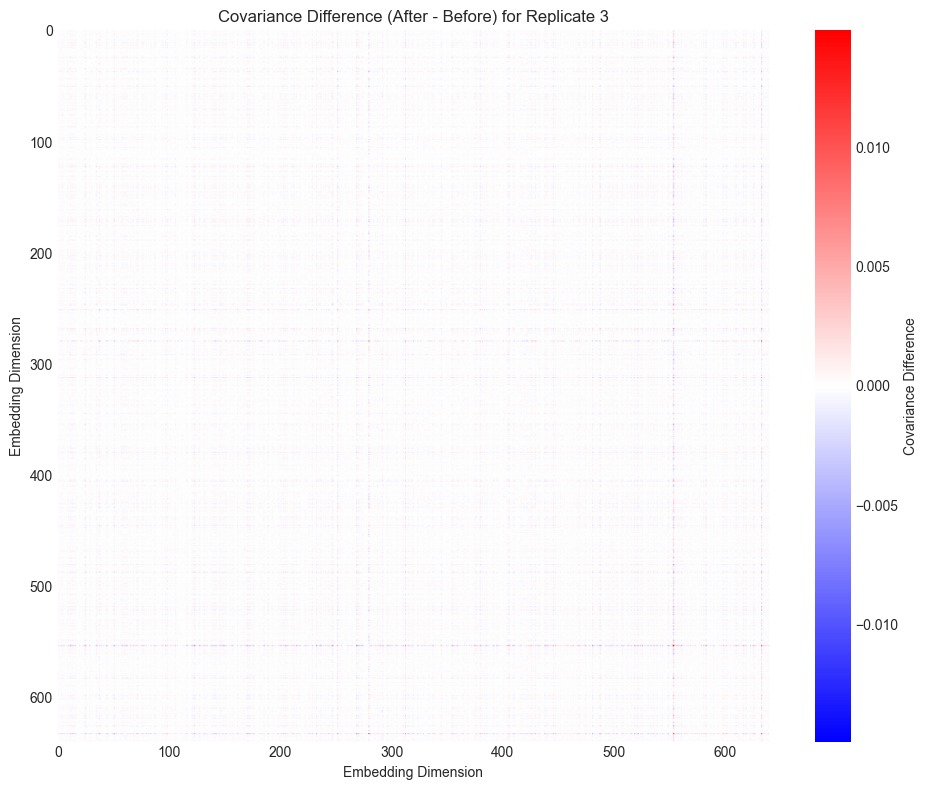

In [98]:

# Plot the differences
import matplotlib.pyplot as plt
for i, cov_diff in enumerate(cov_diffs):
    plt.figure(figsize=(10, 8))
    plt.style.use("seaborn-v0_8-dark")
    plt.imshow(cov_diff, cmap='bwr', vmin=-np.max(np.abs(cov_diff)), vmax=np.max(np.abs(cov_diff)))
    plt.colorbar(label='Covariance Difference')
    plt.title(f'Covariance Difference (After - Before) for Replicate {i+1}')
    plt.xlabel('Embedding Dimension')
    plt.ylabel('Embedding Dimension')
    plt.tight_layout()
    plt.show()

In [14]:
def embedding_df_transfer(embed_df: pd.DataFrame) -> dict:
    """
    Format of embed_df:
         PreNums   PostNums   ProteinSequence  Embeddings
    0  [0, 0, 0]  [0, 0, 0]   MKT...           [[...], [...], ...]
    

    Format of RepNDataFrame:
    generation, embedding, frequency, replicate
    
    
    Key Differences:
    We will not have sites and amino acids. Instead, we will have 
    the N embedding dimensions 
    """
    
    pre_counts = np.array([np.array(x) for x in embed_df["PreNums"].to_list()])
    post_counts = np.array([np.array(x) for x in embed_df["PostNums"].to_list()])
    embeddings = np.array([x for x in embed_df["Embeddings"].to_list()])
    print("done converting to arrays")
    num_reps = pre_counts.shape[1]
    num_gens = 2 # set to 2 for now, pre and post selection
    
    new_df = pd.DataFrame(columns=["Generation", "Embedding", "Frequency", "Replicate"])
    print("initialized new df")
    for rep in range(num_reps):
        # loop through every row
        print(f"on replicate {rep}")
        for i in range(embed_df.shape[0]):
            print(f"on embedding {i}")
            if embeddings[i] is not None:
                # loop through every generation
                for gen in range(num_gens):
                    print(f"on generation {gen}")
                    if gen == 0:
                        freq = pre_counts[i, rep]
                    else:
                        freq = post_counts[i, rep]
                        
                    if gen == 0 and freq == 0:
                        continue
                        
                    new_row = {
                        "Generation": gen,
                        "Embedding": embeddings[i],
                        "Frequency": freq,
                        "Replicate": rep+1
                    }
                    new_df = pd.concat([new_df, pd.DataFrame([new_row])], ignore_index=True)
                    
    return new_df
        
    


In [6]:
import popDMS
import pandas as pd
import pickle
from importlib import reload

def run_inference_calcs(layer_df, output_path):
    """Run the inference calculations:
    WHOLE PIPELINE FROM READING IN EMBEDDINGS DATAFRAME
    """
    """print("bef 0")
    inference_df = embedding_df_transfer(layer_df)
    
    
    # make directory
    if not os.path.exists(output_path):
        os.makedirs(output_path)
    # save inference_df
    inference_df.to_pickle(output_path + '/inference_df.pkl')"""
    
    inference_df = pd.read_pickle(output_path + '/inference_df.pkl')
    
    print(inference_df.head())
    
    print("bef 1")
    data = popDMS.mini_infer_independent_esm(inference_df, n_replicates=3,
                                            output_dir=output_path)
    print("bef 2")
    
    return data
    
    
    
    

  Generation                                          Embedding Frequency  \
0          0  [-1.7897613, -2.3268387, 1.5421044, -2.0009897...       110   
1          1  [-1.7897613, -2.3268387, 1.5421044, -2.0009897...       114   
2          0  [-1.6864641, -2.3490787, 1.5079317, -2.0859497...         1   
3          1  [-1.6864641, -2.3490787, 1.5079317, -2.0859497...         1   
4          1  [-1.7435617, -2.4070325, 1.476325, -1.9813418,...         3   

  Replicate  
0         1  
1         1  
2         1  
3         1  
4         1  
bef 1
0
dx shape: (3, 640)
icov shape: (3, 640, 640)
1
2
Shape of s: (3, 640)
Shape of s: (3, 640)
Shape of s: (3, 640)
Shape of s: (3, 640)
Shape of s: (3, 640)
Shape of s: (3, 640)
Shape of s: (3, 640)
Shape of s: (3, 640)
Shape of s: (3, 640)
Shape of s: (3, 640)
Shape of s: (3, 640)
Shape of s: (3, 640)
Shape of s: (3, 640)
Shape of s: (3, 640)
Shape of s: (3, 640)
Shape of s: (3, 640)
Shape of s: (3, 640)
Shape of s: (3, 640)
Shape of s: (3, 64

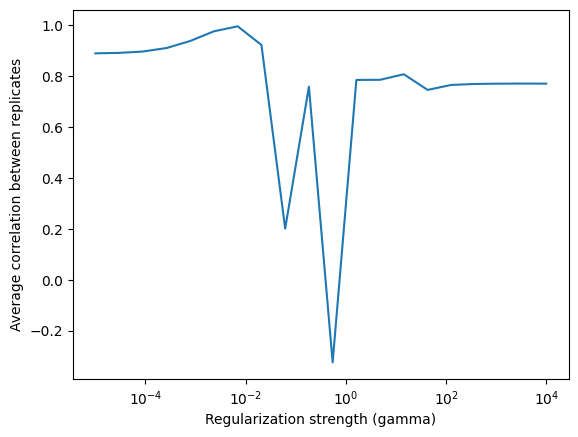

Found best regularization strength gamma = 2.3e-03, R = 0.97


TypeError: 'int' object is not iterable

In [10]:
reload(popDMS)

data = run_inference_calcs(None, '/Users/dylanwells/CodingProjects/popDMS/esmDMS/data/inference_results/layer29/')

In [11]:
whole_df = pd.read_pickle(pwd + '/data/sequence_data/all_reps_BF520_protein_embeddings.pkl')


In [12]:
print(whole_df.head())
# Drop rows with None embeddings
nonzero_df = whole_df[whole_df["Embeddings"].notnull()].reset_index(drop=True)
print(nonzero_df.head())
# Print the shape of an embedding
print(nonzero_df["Embeddings"][0].shape)

layer_dfs = []
for layer in range(30):
    layer_df = nonzero_df.copy()
    layer_df["Embeddings"] = layer_df["Embeddings"].apply(lambda x: x[layer])
    layer_dfs.append(layer_df)
    #layer_df.to_pickle(pwd + f'/data/sequence_data/BF520_protein_embeddings_layer{layer}.pkl')
    #print(f"Wrote layer {layer} dataframe to pickle")

          PreNums         PostNums  \
0       [0, 0, 0]        [0, 0, 0]   
1       [0, 0, 0]        [0, 0, 0]   
2       [0, 0, 0]        [0, 0, 0]   
3       [0, 0, 0]        [0, 0, 0]   
4  [110, 164, 94]  [114, 173, 207]   

                                     ProteinSequence  \
0  KGNLWVTVYYGVPVWKDAETTLFCASDAKAYDAEVHNIWATHACVP...   
1  NGNLWVTVYYGVPVWKDAETTLFCASDAKAYDAEVHNIWATHACVP...   
2  KGNLWVTVYYGVPVWKDAETTLFCASDAKAYDAEVHNIWATHACVP...   
3  NGNLWVTVYYGVPVWKDAETTLFCASDAKAYDAEVHNIWATHACVP...   
4  TGNLWVTVYYGVPVWKDAETTLFCASDAKAYDAEVHNIWATHACVP...   

                                          Embeddings  
0                                               None  
1                                               None  
2                                               None  
3                                               None  
4  [[-0.031634934, -0.027693663, -0.043913726, -0...  
          PreNums         PostNums  \
0  [110, 164, 94]  [114, 173, 207]   
1       [1, 0, 0]        [1,

In [5]:
data = run_inference_calcs(None, '/Users/dylanwells/CodingProjects/popDMS/esmDMS/data/inference_results/layer29/')

  Generation                                          Embedding Frequency  \
0          0  [-1.7897613, -2.3268387, 1.5421044, -2.0009897...       110   
1          1  [-1.7897613, -2.3268387, 1.5421044, -2.0009897...       114   
2          0  [-1.6864641, -2.3490787, 1.5079317, -2.0859497...         1   
3          1  [-1.6864641, -2.3490787, 1.5079317, -2.0859497...         1   
4          1  [-1.7435617, -2.4070325, 1.476325, -1.9813418,...         3   

  Replicate  
0         1  
1         1  
2         1  
3         1  
4         1  
bef 1
0
dx shape: (3, 640)
icov shape: (3, 640, 640)
1
2
Shape of s: (3, 640)
(640, 640)
(640,)
temp: [ 951.27335617 1175.83047916 1170.13939958 1088.78726053 1155.84026273
  898.53022082 1191.32696685 1084.39577178 1271.10110956  869.64670008
 1520.69033871  581.59044453 1352.28750692 1108.61926947  996.11351124
 1164.32147775 1031.022692   1364.77651942 1261.73256733 1262.54154024
 1005.03176662 1118.92456096 1226.98612414 1254.51467829 1567.72657

ValueError: setting an array element with a sequence.

In [16]:
test = pd.read_pickle('/data/inference_results/layer29/inference_df.pkl')

In [18]:
print(test.tail())

       Generation                                          Embedding  \
228315          1  [-1.7823409, -2.3352962, 1.5169015, -1.99391, ...   
228316          0  [-1.7894776, -2.3728926, 1.4762079, -1.9857116...   
228317          1  [-1.7894776, -2.3728926, 1.4762079, -1.9857116...   
228318          0  [-1.7894776, -2.3728926, 1.4762079, -1.9857116...   
228319          1  [-1.7894776, -2.3728926, 1.4762079, -1.9857116...   

       Frequency Replicate  
228315         6         2  
228316        19         2  
228317         6         2  
228318        65         2  
228319        70         2  


In [ ]:
print(count_total_proteins(data_dir+'BF520_mutDNA-1_codoncounts.csv'))
print(count_total_proteins(data_dir+'BF520_mutvirus-1_codoncounts.csv'))



In [30]:
print(len("MRVKGIQMNSQHLLRWGIMILGMIMICSVAGNLWVTVYYGVPVWKDAETTLFCASDAKAYDAEVHNIWATHACVPTDPNPQEINLENVTEEFNMWKNNMVEQMHTDIISLWDQGLKPCVKLTPLCVTLDCHNVTYNSDMKEEITNCSYNVTTVIRDKKQKVSSLFYKLDVVQIGGNNRTNSQYRLINCNTSAITQACPKVTFEPIPIHYCAPAGFAILKCKDEKFNGTGLCKNVSTVQCTHGIKPVVSTQLLLNGSLAEGEVRIRSENITNNAKNIIVQLDSPVTINCIRPNNNTRKSVHLGPGQAFYATGDIIGEIRQAHCNVSKKEWNSTLQKVANQLRPYFKNTIIKFASSTGGDLEITTHSFNCGGEFFYCNTSGLFNSTWESNNSTENITLQCRIKQIVNMWQRAGQAIYAPPIPGVIRCESNITGLILTRDGGNNSANETFRPGGGDMRDNWRSELYKYKVVKIEPIGVAPTRAKRRVVEREKRAVGIGAVFIGFLGAAGSTMGAASVTLTVQARQLLSGIVQQQSNLLRAIEAQQHLLKLTVWGIKQLQARVLAVERYLKDQQLLGIWGCSGKLICTTNVPWNSSWSNKSQDEIWGNMTWLQWDKEVSNYTQIIYTLIEESQNQQEKNEQDLLALDKWASLWNWFNISQWLWYIKIFIIIVGGLIGLRIVFAVLSVINRVRQGYSPLSFQTRTPNPGELDRPGRIEEEGGEQDRGRSIRLVSGFLALAWDDLRSLCLFSYHRLRDFILIATRTVELLGHSSLKGLRLGWESLKYLGNLLVYWGRELKISAINLVDTIAIAVAGWTDRVIELGQRLCRAILHIPRRIRQGFERALL"))

842


In [43]:
from Bio import SeqIO

ref_seqs = []
for record in SeqIO.parse("/Users/dylanwells/CodingProjects/popDMS/esmDMS/data/raw_data/HIV-1_env_gap_strip.fasta", "fasta"):
    ref_seqs.append(str(record.seq))

# Create a consensus sequence
from collections import Counter
consensus_sequence = ""
for i in range(len(ref_seqs[0])):
    column = [seq[i] for seq in ref_seqs]
    most_common_aa = Counter(column).most_common(1)[0][0]
    consensus_sequence += most_common_aa


print(consensus_sequence)


pwd = os.getcwd()

data_dir = pwd + '/data/raw_data/'
reference_sequence_file = data_dir + "BF520_Reference_sequence.txt"
reference_sequence = get_reference_sequence(reference_sequence_file)
    

MRVKGIQMNSQHLLRWGIMILGMIMICSVAGNLWVTVYYGVPVWKDAETTLFCASDAKAYDAEVHNIWATHACVPTDPNPQEINLENVTEEFNMWKNNMVEQMHTDIISLWDQGLKPCVKLTPLCVTLDCHNVTYNSDMKEEITNCSYNVTTVIRDKKQKVSSLFYKLDVVQIGGNNRTNSQYRLINCNTSAITQACPKVTFEPIPIHYCAPAGFAILKCKDEKFNGTGLCKNVSTVQCTHGIKPVVSTQLLLNGSLAEGEVRIRSENITNNAKNIIVQLASPVTINCIRPNNNTRKSVHLGPGQAFYATGDIIGEIRQAHCNVSKKEWNSTLQKVANQLRPYFKNNTIIKFNSSGGDLEITTHSFNCGGEFFYCNTSGLFNSTWEFNNSTENITLQCRIKQIINMWQRAGQAIYAPPIPGVIRCKSNITGLILTRDGGNKNTSETFRPGGGDMRDNWRSELYKYKVVKIEPIGVAPTRAKRRVVEREKRAVGIGAVFIGFLGAAGSTMGAASVTLTVQARQLLSGIVQQQSNLLRAIEAQQHLLKLTVWGIKQLQARVLAVERYLKDQQLLGIWGCSGKLICTTNVPWNSSWSNKSQDEIWGNMTWLQWDKEVSNYTQIIYTLIEESQNQQEKNEQDLLALDKWASLWNWFNISQWLWYIKIFIIIVGGLIGLRIVFAVLSVINRVRQGYSPLSFQTRTPNPGELDRPGRIEEEGGEQDRGRSIRLVSGFLALAWDDLRSLCLFSYHRLRDFILIATRTVELLGHSSLKGLRLGWESLKYLGNLLVYWGRELKISAINLCDTIAIAVAGWTDRVIELGQRLCRAILHIPRRIRQGFERALL


In [58]:

len_bef = 10

print(" "*len_bef + reference_sequence)
print(consensus_sequence[29-len_bef:29+len(reference_sequence)])

consensus_seq_shortened = consensus_sequence[29:29+len(reference_sequence)]

print(len(reference_sequence))
print(len(consensus_seq_shortened))

diffs = 0
j = 0
for i in range(len(reference_sequence)):
    if reference_sequence[i] != consensus_seq_shortened[j]:
        diffs += 1
        print(i, j,  reference_sequence[i], consensus_seq_shortened[j])
    else:
        j += 1


print(f"Total differences: {diffs}")

          AGNLWVTVYYGVPVWKDAETTLFCASDAKAYDAEVHNIWATHACVPTDPNPQEINLENVTEEFNMWKNNMVEQMHTDIISLWDQGLKPCVKLTPLCVTLDCHNVTYNITSDMKEEITNCSYNVTTVIRDKKQKVSSLFYKLDVVQIGGNNRTNSQYRLINCNTSAITQACPKVTFEPIPIHYCAPAGFAILKCKDEKFNGTGLCKNVSTVQCTHGIKPVVSTQLLLNGSLAEGEVRIRSENITNNAKNIIVQLASPVTINCIRPNNNTRKSVHLGPGQAFYATDGIIGEIRQAHCNVSKKEWNSTLQKVANQLRPYFKNNTIIKFANSSGGDLEITTHSFNCGGEFFYCNTSGLFNSTWEFNSTWNNSNSTENITLQCRIKQIINMWQRAGQAIYAPPIPGVIRCKSNITGLILTRDGGSNKNTSETFRPGGGDMRDNWRSELYKYKVVKIEPIGVAPTRAKRRVVEREKRAVGIGAVFIGFLGAAGSTMGAASVTLTVQARQLLSGIVQQQSNLLRAIEAQQHLLKLTVWGIKQLQARVLAVERYLKDQQLLGIWGCSGKLICTTNVPWNSSWSNKSQDEIWGNMTWLQWDKEVSNYTQIIYTLIEESQNQQEKNEQDLLALDKWASLWNWFNISQWLWYIKIFIIIVGGLIGLRIVFAVL
ILGMIMICSVAGNLWVTVYYGVPVWKDAETTLFCASDAKAYDAEVHNIWATHACVPTDPNPQEINLENVTEEFNMWKNNMVEQMHTDIISLWDQGLKPCVKLTPLCVTLDCHNVTYNSDMKEEITNCSYNVTTVIRDKKQKVSSLFYKLDVVQIGGNNRTNSQYRLINCNTSAITQACPKVTFEPIPIHYCAPAGFAILKCKDEKFNGTGLCKNVSTVQCTHGIKPVVSTQLLLNGSLAEGEVRIRSENITNNAKNIIVQLASPVTINCIRPNNNTRKSVHLGPGQAFYATGDIIGEIRQAHCNVSKKEWNSTLQKVANQLRPYFKN